In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print(x_train.shape) 
print(y_train.shape) 
print(x_test.shape) 
print(y_test.shape)   


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
x_train[:5]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
   

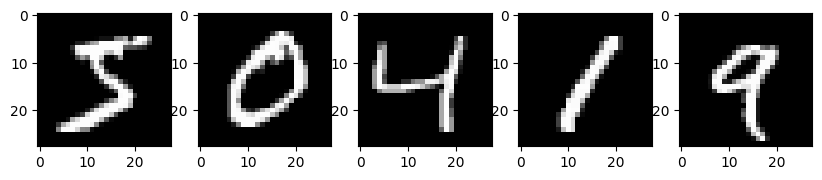

In [5]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1) #subplot(rows, cols, index)
    plt.imshow(x_train[i],cmap='gray')

Reshape (CNN need 4d input)

In [6]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  =  x_test.reshape(-1, 28, 28,1)

Normilization and ONE-HOT Coding

In [7]:
x_train = x_train/255.0
x_test  = x_test/255.0


from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)

CNN Architecture

In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential()

# 1st Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(.5))
model.add(Dense(10, activation='softmax'))

# model summery 
model.summary()

C:\Users\shubham yadav\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
for layer in model.layers:
    print(layer.name,'->', layer.output.shape)


conv2d -> (None, 26, 26, 32)
max_pooling2d -> (None, 13, 13, 32)
conv2d_1 -> (None, 11, 11, 64)
max_pooling2d_1 -> (None, 5, 5, 64)
flatten -> (None, 1600)
dense -> (None, 128)
dropout -> (None, 128)
dense_1 -> (None, 10)


In [10]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)


You must install pydot (`pip install pydot`) for `plot_model` to work.


In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train the model

In [12]:
History = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9031 - loss: 0.3232 - val_accuracy: 0.9837 - val_loss: 0.0605
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9695 - loss: 0.1002 - val_accuracy: 0.9873 - val_loss: 0.0458
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9788 - loss: 0.0717 - val_accuracy: 0.9885 - val_loss: 0.0394
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9814 - loss: 0.0614 - val_accuracy: 0.9892 - val_loss: 0.0380
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9852 - loss: 0.0496 - val_accuracy: 0.9898 - val_loss: 0.0360
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9868 - loss: 0.0439 - val_accuracy: 0.9915 - val_loss: 0.0334
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9881 - loss: 0.0376 - val_accuracy: 0.9915 - val_loss: 0.0346
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9893 - loss: 0.0336 - val_acc

Hence the model is fully Generalization (NO Overfitting)

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
train_loss, train_acc = model.evaluate(x_train, y_train)
print("\nTrain Accuracy:", train_acc)
print("Train loss:", test_loss, '\n')

print("Test Accuracy:", test_acc)
print("Test loss:", test_loss)
# NO overfitting

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9921 - loss: 0.0226
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9969 - loss: 0.0111

Train Accuracy: 0.9968500137329102
Train loss: 0.02261047437787056 

Test Accuracy: 0.9921000003814697
Test loss: 0.02261047437787056


In [21]:
plt.figure()
plt.plot(train_acc['accuracy'], label='Train Accuracy')
plt.plot(test_acc['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


TypeError: 'float' object is not subscriptable

<Figure size 640x480 with 0 Axes>

In [18]:
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)


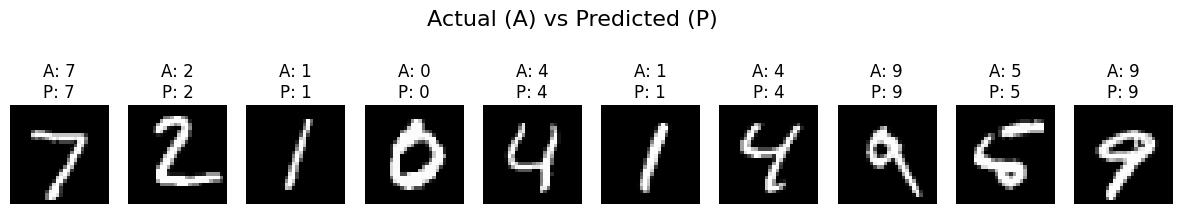

In [23]:
import matplotlib.pyplot as plt

num_images = 10
plt.figure(figsize=(15, 3))

for i in range(num_images):
    plt.subplot(1, num_images, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"A: {y_true[i]}\nP: {y_pred_class[i]}")
    plt.axis('off')

plt.suptitle("Actual (A) vs Predicted (P)", fontsize=16)
plt.show()


In [ ]:
wrong_idx = np.where(y_pred_class != y_true)[0]
print(len(wrong_idx))
# out of 10000 image on test dats modle predict 79 wronge image

79


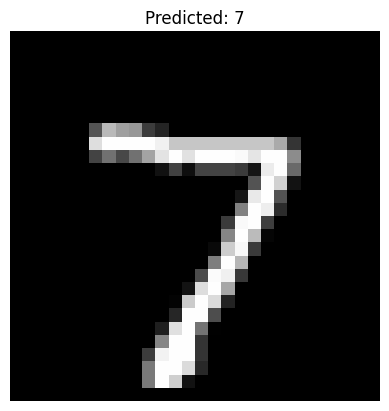

In [ ]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(y_pred[0])}")
plt.axis('off')
plt.show()


Image that predict wrong by the model during testing

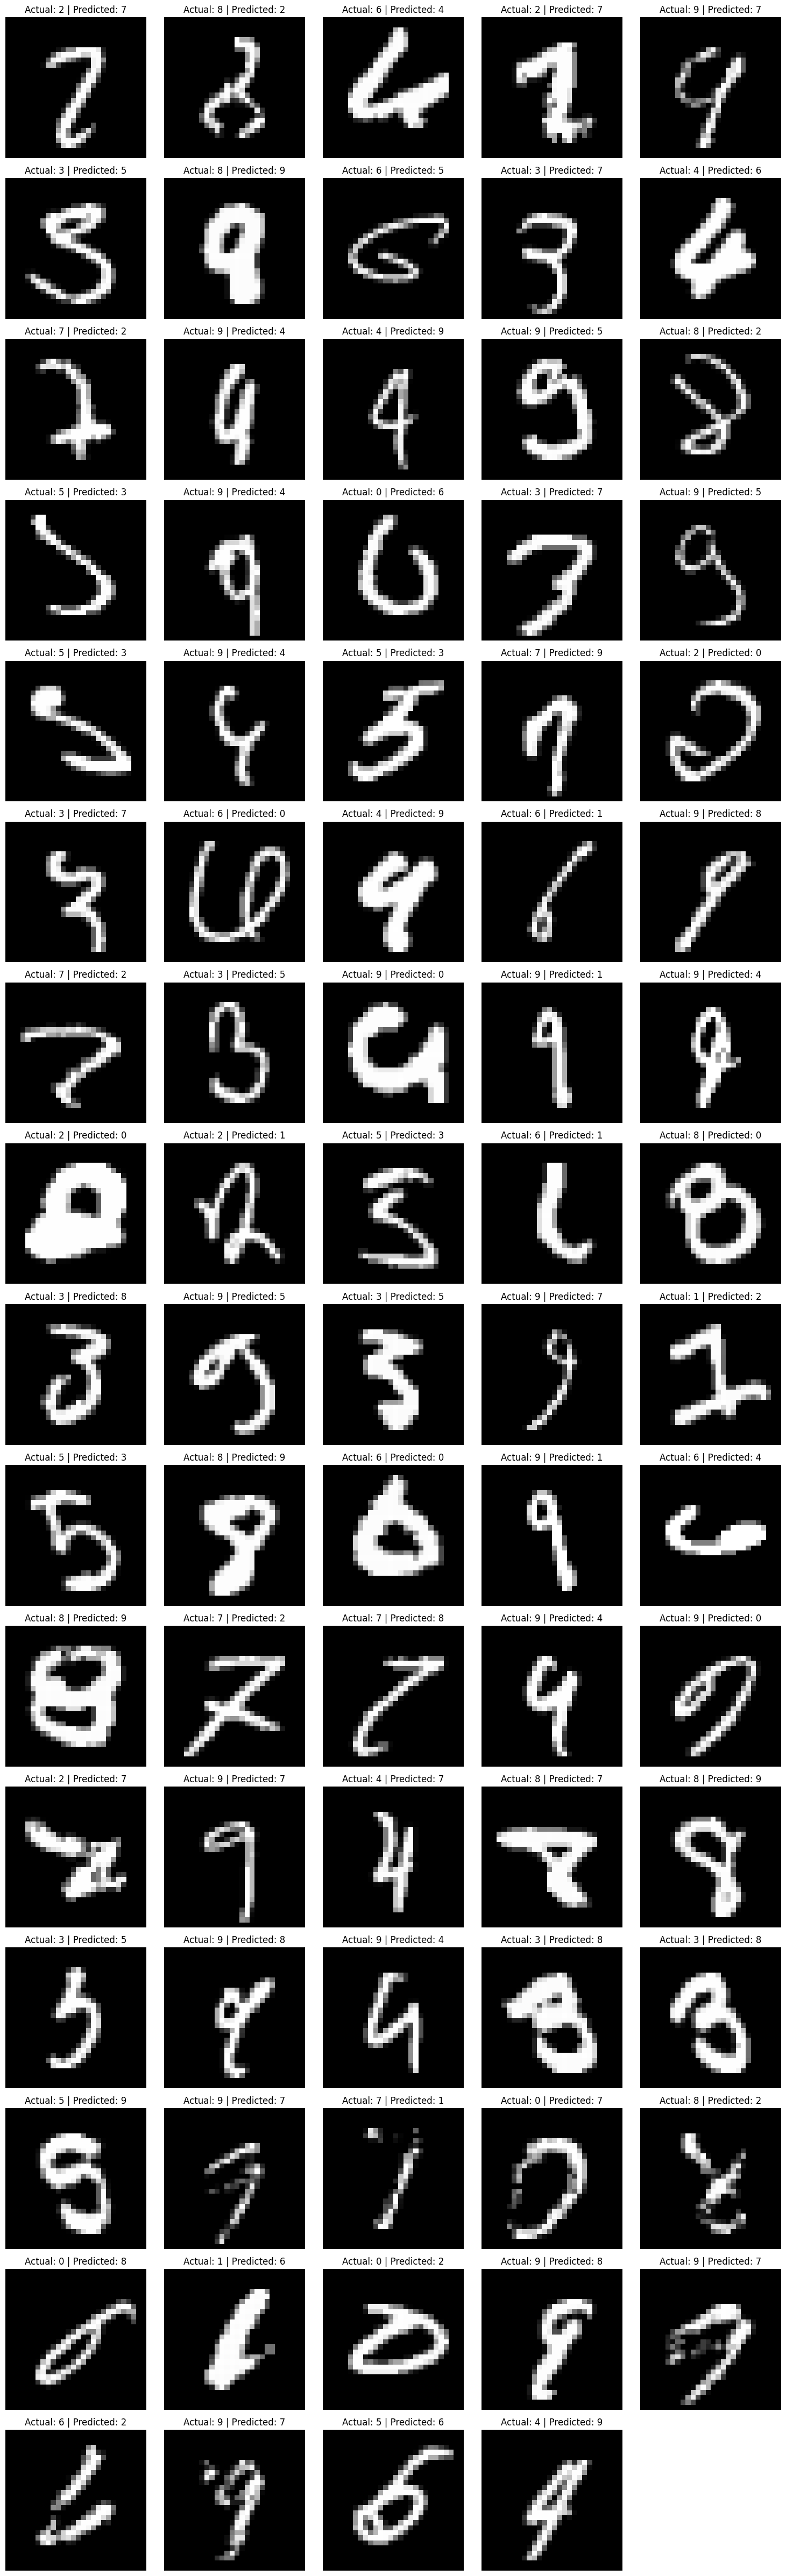

In [ ]:
wrong_idx = np.where(y_pred_class != y_true)[0]
# it gives the index of wronge predection 

cols = 5
rows = int(len(wrong_idx)/cols)+1

plt.figure(figsize=(15, rows*3))

for i in range(len(wrong_idx)):
    idx = wrong_idx[i]
    
    plt.subplot(rows, cols, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title("Actual: "+ str(y_true[idx]) + " | Predicted: "+ str(y_pred_class[idx]))
              
    plt.axis('off')
    plt.tight_layout()